## Learning objectives
- Work only with **alternative explanations** in the ensured framework;
- Use a baseline triangular plot before any filtering in each setting;
- Compare `super`, `semi`, `counter`, `ensured`, and `pareto` alternatives;
- Use ensured ranking controls (`rnk_metric`, `rnk_weight`, `filter_top`) with and without triangular style.

## Time to run
~5–15 min depending on dataset size, calibration, and plotting backend.

# Ensured framework notebook: alternatives-first workflow
Author: Tuwe Löfström (tuwe.lofstrom@ju.se)  
Copyright 2023 Tuwe Löfström  
License: BSD 3 clause

This notebook focuses only on **alternative explanations** and ensured-style filtering/ranking.
We always start with an **unfiltered triangular baseline** and then compare filtered views.

**Method naming note:** the API method is `ensured_explanations` (not `ensure_explanations`).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from calibrated_explanations import WrapCalibratedExplainer, __version__

warnings.filterwarnings("ignore", category=UserWarning)

print(f"calibrated_explanations {__version__}")

# Global ensured-framework controls (used across all sections)
MAX_RULE_SIZE = 4
FILTER_TOP_DEFAULT = 5
RNK_WEIGHTS = [-1.0, -0.5, 0.0, 0.5, 1.0]
THRESHOLD_REG = 300
INCLUDE_POTENTIAL = True
TESTS_TO_PLOT=2

calibrated_explanations v0.11.1


In [3]:
from sklearn.datasets import fetch_openml

dataset = fetch_openml(name="wine", version=7, as_frame=True, parser="auto")

X = dataset.data.values.astype(float)
y = (dataset.target.values == "True").astype(int)

feature_names = dataset.feature_names

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
_, x_plot, _, y_plot = train_test_split(
    x_test, y_test, test_size=TESTS_TO_PLOT, random_state=42, stratify=y_test
)

X_prop_train, x_cal, y_prop_train, y_cal = train_test_split(
    x_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

## Classification: ensured alternatives workflow
Create and train a wrapped classifier, then calibrate it for ensured-style alternatives analysis.

In [4]:
from sklearn.ensemble import RandomForestClassifier

from calibrated_explanations import __version__

print(f"calibrated_explanations {__version__}")

classifier = WrapCalibratedExplainer(RandomForestClassifier(random_state=42))
display(classifier)

calibrated_explanations v0.11.1


WrapCalibratedExplainer(learner=RandomForestClassifier(random_state=42), fitted=False, calibrated=False)

Fit the learner on the proper training split.

In [5]:
classifier.fit(X_prop_train, y_prop_train)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(random_state=42), fitted=True, calibrated=False)

Calibrate with the calibration split so alternative intervals are calibrated.

In [6]:
classifier.calibrate(x_cal, y_cal, feature_names=feature_names)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(random_state=42), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, learner=RandomForestClassifier(random_state=42)))

Plot the full classification test set with and without known targets (`y_test`) using the explainer-level plot.

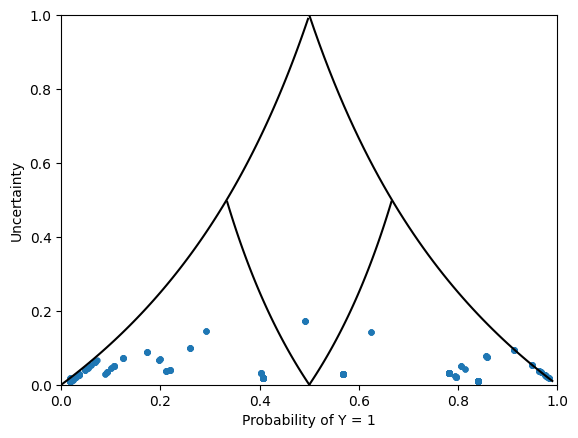

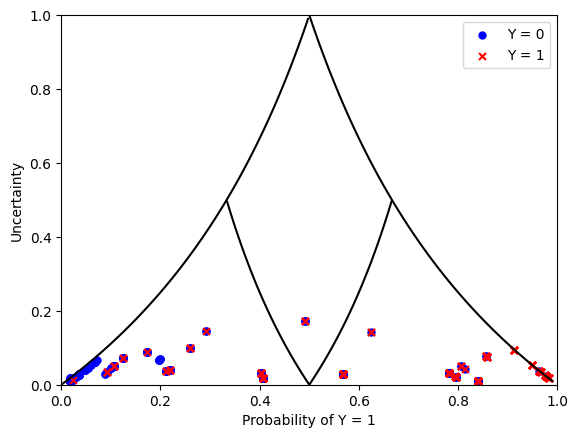

In [7]:
classifier.plot(x_test)
classifier.plot(x_test, y_test)

### Baseline first (unfiltered)
Before any ensured filtering, extract all alternatives and plot a triangular baseline for reference.

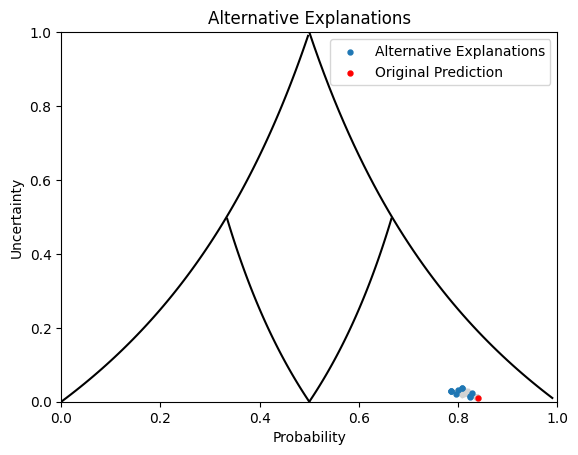

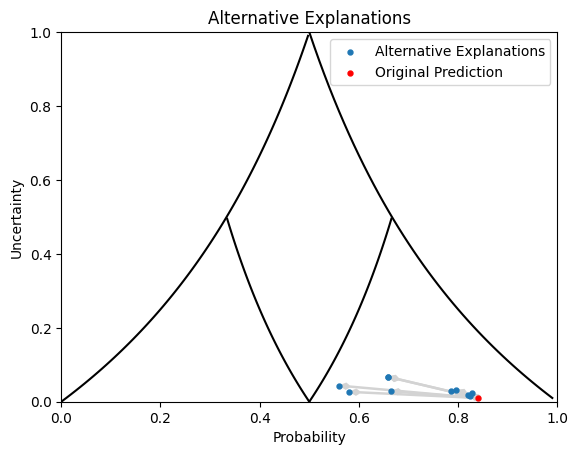

In [8]:
classification_alternatives = classifier.explore_alternatives(x_plot)
classification_alternatives.add_conjunctions(max_rules_size=MAX_RULE_SIZE)
classification_alternatives.plot(style="triangular")

### Ensured filtering methods
Create filtered views from the same baseline alternatives: `super`, `semi`, `counter`, `ensured`, and `pareto`.

In [9]:
classification_views = {
    "super": classification_alternatives.super_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
    "semi": classification_alternatives.semi_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
    "counter": classification_alternatives.counter_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
    "ensured": classification_alternatives.ensured_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
    "pareto": classification_alternatives.pareto_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
}
list(classification_views.keys())

['super', 'semi', 'counter', 'ensured', 'pareto']

Compare each filtered set in triangular style using ensured ranking.

Classification view: super
Classification view: semi


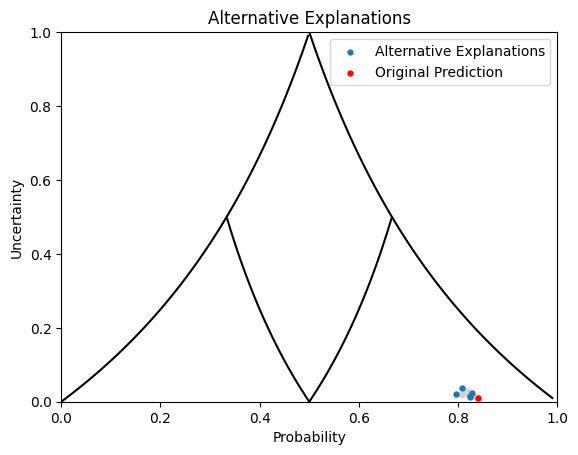

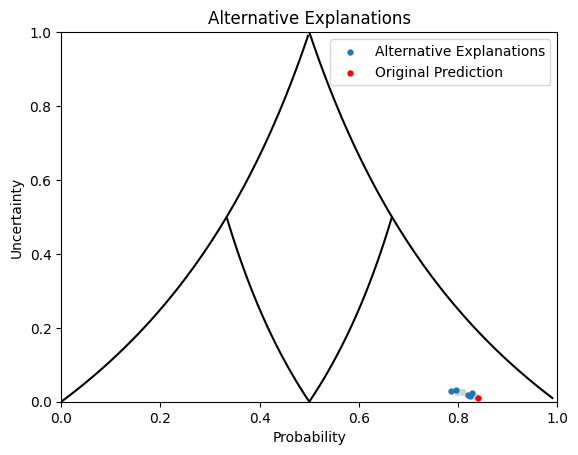

Classification view: counter


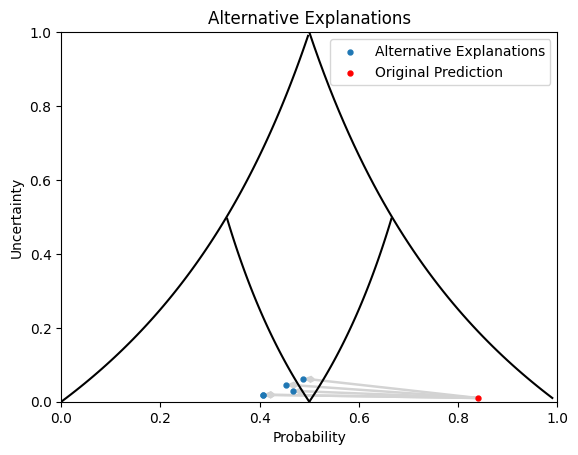

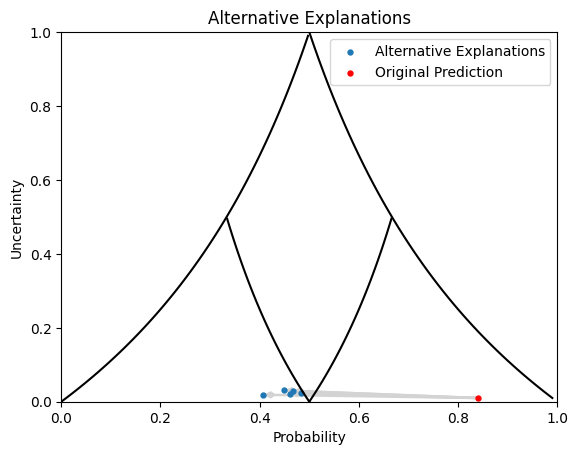

Classification view: ensured
Classification view: pareto


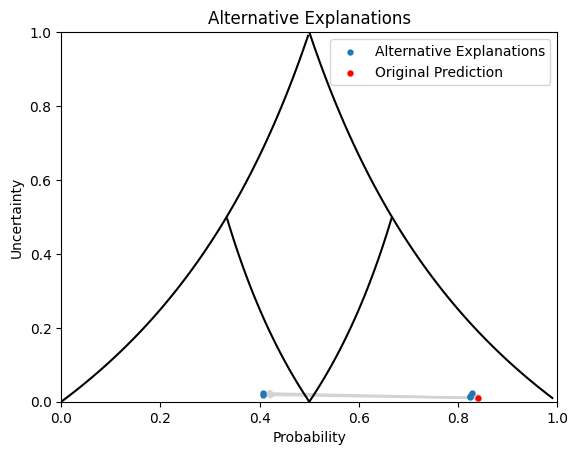

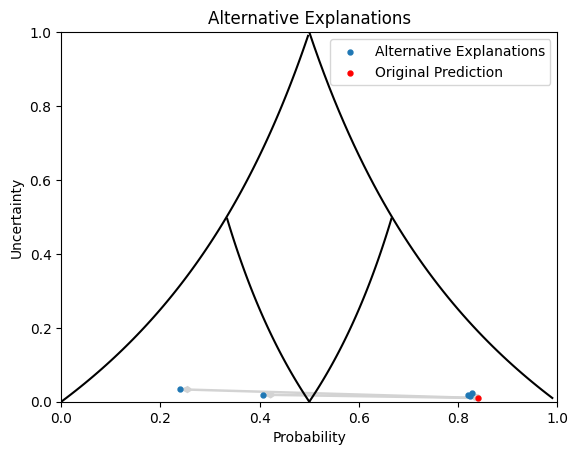

In [10]:
for name, view in classification_views.items():
    print(f"Classification view: {name}")
    view.plot(
        style="triangular",
        rnk_metric="ensured",
        rnk_weight=0.5,
        filter_top=FILTER_TOP_DEFAULT,
    )

Ranking sweep on the baseline (no filtering) using `rnk_metric="ensured"` and several `rnk_weight` values in `[-1, 1]`.

Baseline ranking with rnk_weight=-1.0


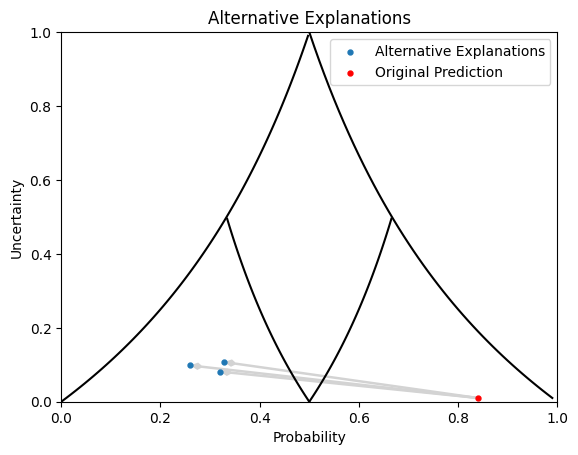

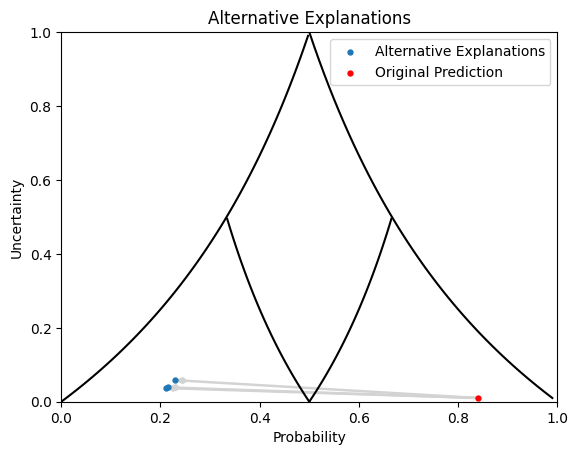

Baseline ranking with rnk_weight=-0.5


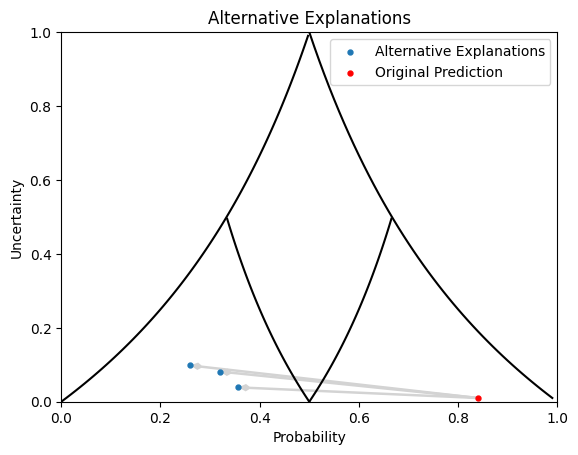

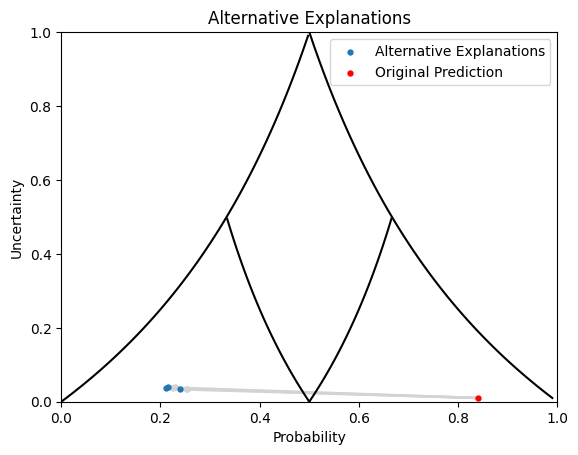

Baseline ranking with rnk_weight=0.0


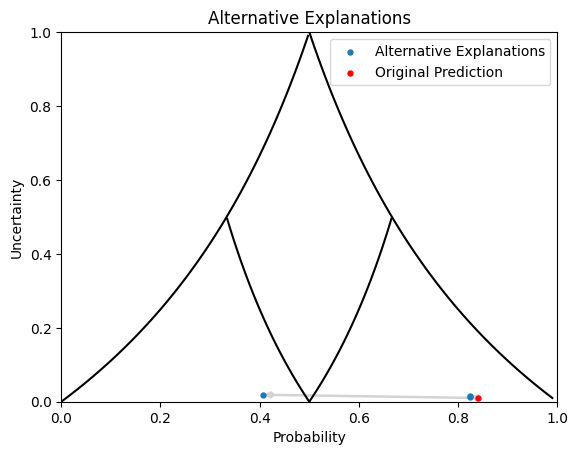

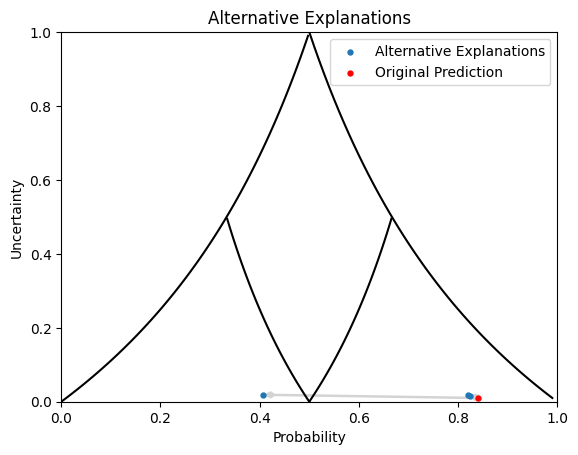

Baseline ranking with rnk_weight=0.5


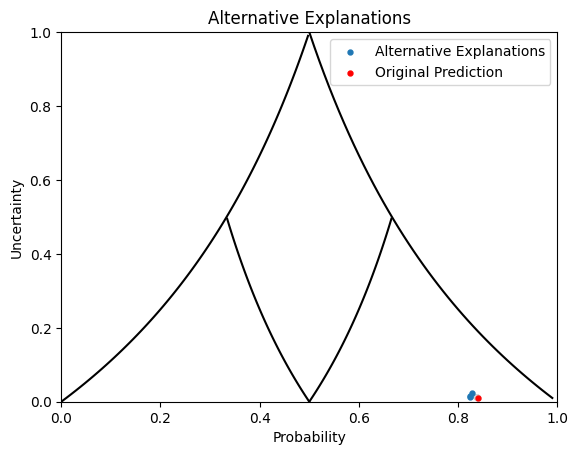

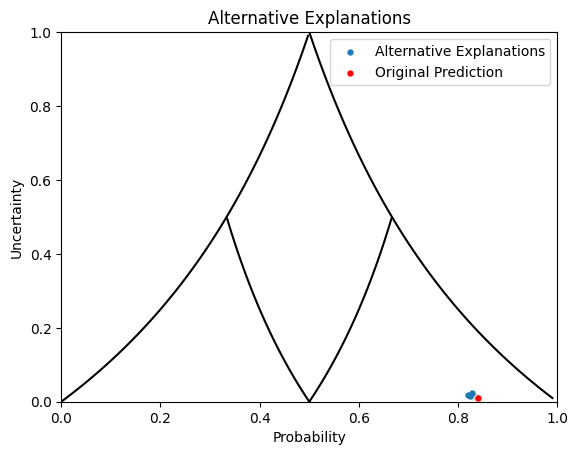

Baseline ranking with rnk_weight=1.0


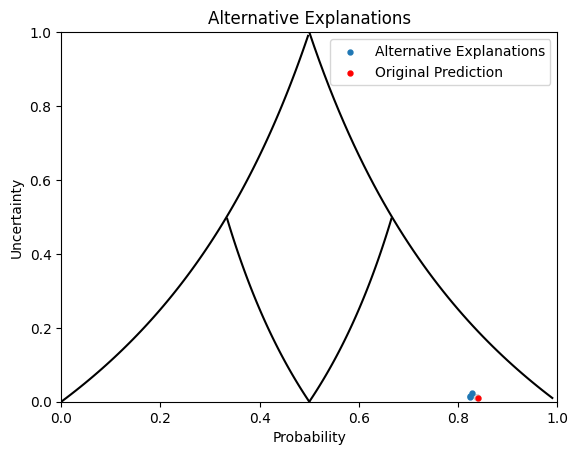

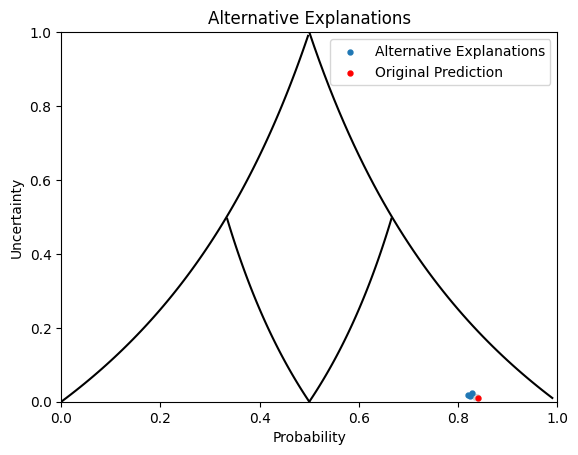

In [11]:
for weight in RNK_WEIGHTS:
    print(f"Baseline ranking with rnk_weight={weight}")
    classification_alternatives.plot(
        style="triangular",
        rnk_metric="ensured",
        rnk_weight=weight,
        filter_top=3,
    )

Add conjunctions globally with `max_rule_size=MAX_RULE_SIZE` and compare triangular vs regular plotting.

In [12]:
classification_ensured_conj = classification_views["ensured"].add_conjunctions(
    max_rule_size=MAX_RULE_SIZE
)
classification_ensured_conj.plot(
    style="triangular",
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=FILTER_TOP_DEFAULT,
    
 )
classification_ensured_conj.plot(
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=FILTER_TOP_DEFAULT,
    
 )

You can still plot a single explanation in both regular and triangular styles with ensured ranking controls.

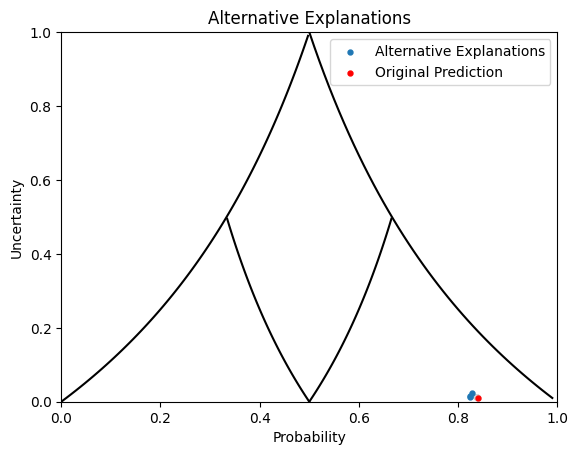

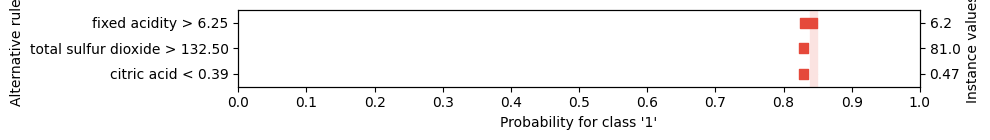

In [13]:
classification_views["pareto"][0].plot(
    style="triangular",
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=3,
    
 )
classification_views["pareto"][0].plot(
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=3,
    
 )

The baseline-first pattern above is reused unchanged for probabilistic and plain regression alternatives below.

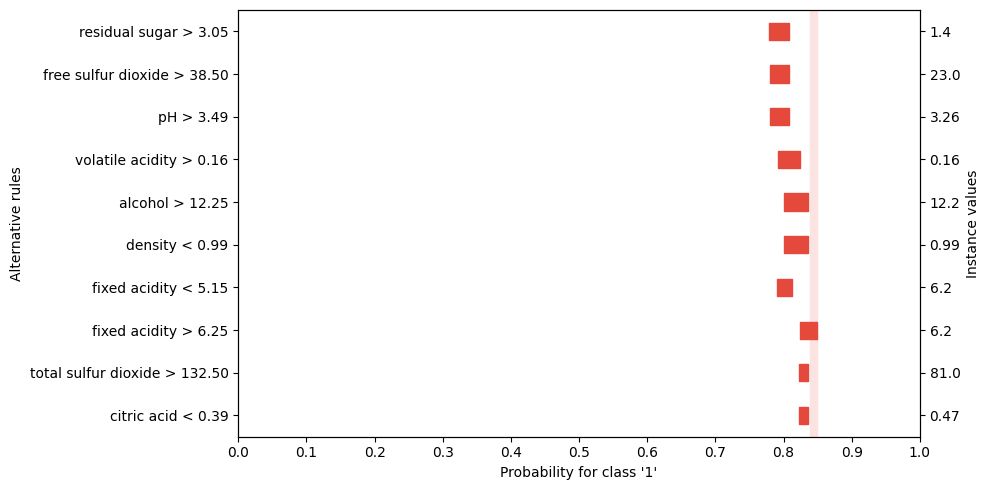

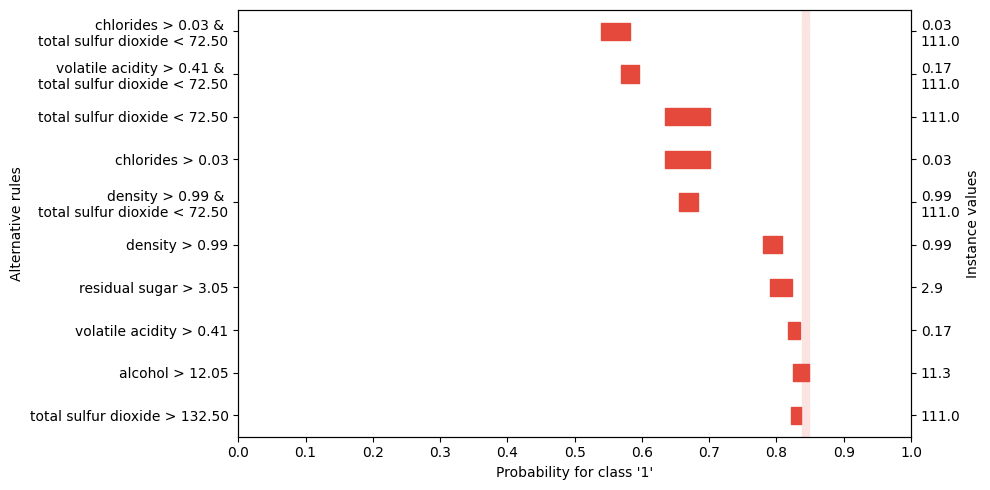

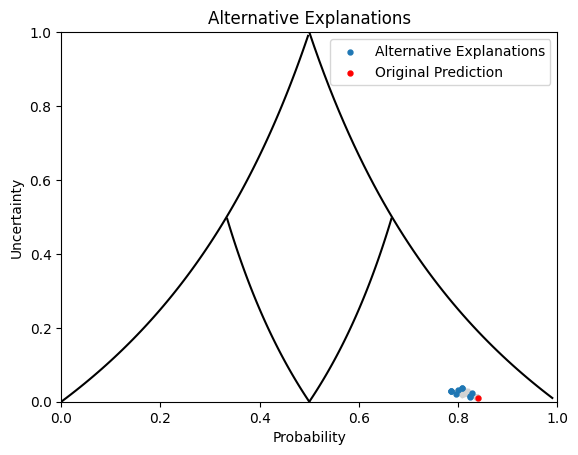

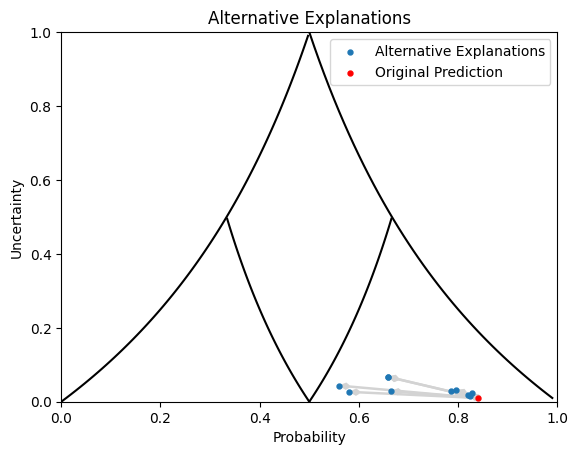

In [14]:
classification_alternatives.plot(filter_top=10, )
classification_alternatives.plot(style="triangular", filter_top=10, )

## Regression setup
Next we prepare one regressor and then run two ensured alternatives workflows:
1. probabilistic regression (`threshold=THRESHOLD_REG`)
2. plain regression (`threshold` omitted)

In [15]:
dataset = "housing.csv"
delimiter = ";"
categorical_labels = {8: {0: "INLAND", 1: "NEAR BAY", 2: "<1H OCEAN", 3: "NEAR OCEAN", 4: "ISLAND"}}

filename = "../../data/reg/" + dataset
df = pd.read_csv(filename, delimiter=delimiter, dtype=np.float64)
target = "median_house_value"
df.dropna(inplace=True)
X, y = df.drop(target, axis=1), df[target]
y = y / 1000
feature_names = df.drop(target, axis=1).columns

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=[bool(y_ < THRESHOLD_REG) for y_ in y]
)

plot_idx = []
plot_idx.append([i for i, y_ in enumerate(y_test) if bool(y_ < THRESHOLD_REG and y_ > THRESHOLD_REG*0.8)][:TESTS_TO_PLOT//2])
plot_idx.append([i for i, y_ in enumerate(y_test) if bool(y_ > THRESHOLD_REG and y_ < THRESHOLD_REG*1.2)][:TESTS_TO_PLOT//2])
plot_idx = np.concatenate(plot_idx)
print(plot_idx)
x_plot = x_test.iloc[plot_idx, :]
y_plot = y_test.iloc[plot_idx]

X_prop_train, x_cal, y_prop_train, y_cal = train_test_split(
    x_train, y_train, random_state=42, test_size=0.25, stratify=[bool(y < THRESHOLD_REG) for y in y_train]
)
print(y_plot, THRESHOLD_REG)

[12 29]
6759    282.6
7710    302.0
Name: median_house_value, dtype: float64 300


Create and train the wrapped regressor that will be reused in both regression alternatives workflows.

In [16]:
from sklearn.ensemble import RandomForestRegressor

regressor = WrapCalibratedExplainer(RandomForestRegressor(random_state=42))
display(regressor)

WrapCalibratedExplainer(learner=RandomForestRegressor(random_state=42), fitted=False, calibrated=False)

We now fit our model using the proper training set.

In [17]:
regressor.fit(X_prop_train, y_prop_train)
display(regressor)

WrapCalibratedExplainer(learner=RandomForestRegressor(random_state=42), fitted=True, calibrated=False)

Calibrate once; then we only work with alternatives and ensured filtering/ranking.

In [18]:
regressor.calibrate(
    x_cal, y_cal, feature_names=feature_names, categorical_labels=categorical_labels
)
display(regressor)

WrapCalibratedExplainer(learner=RandomForestRegressor(random_state=42), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=regression, learner=RandomForestRegressor(random_state=42), difficulty_estimator=None))

## Probabilistic regression alternatives (`threshold=THRESHOLD_REG`)
Baseline first: show all alternatives in triangular style before any ensured filtering.

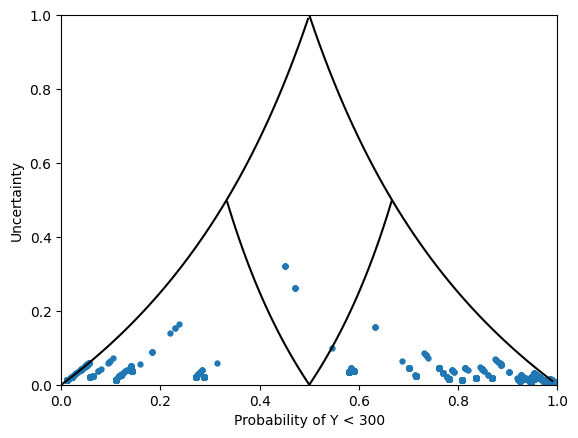

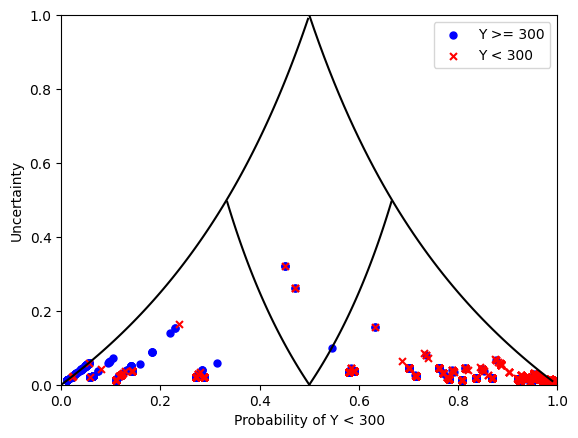

In [19]:
regressor.plot(x_test, threshold=THRESHOLD_REG, show=False)
regressor.plot(x_test, y_test, threshold=THRESHOLD_REG, show=False)

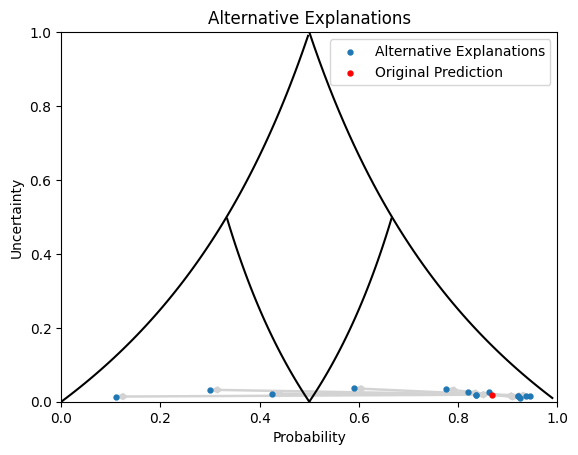

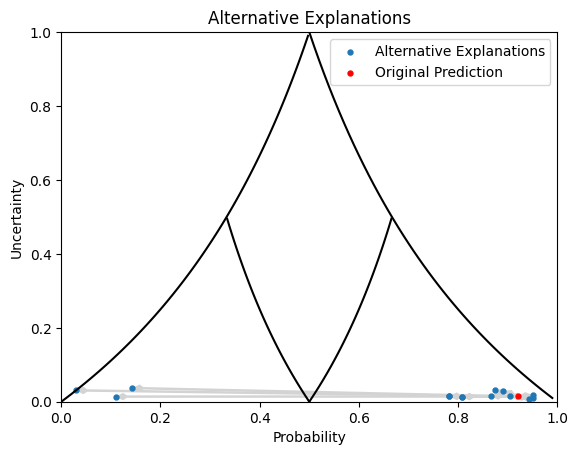

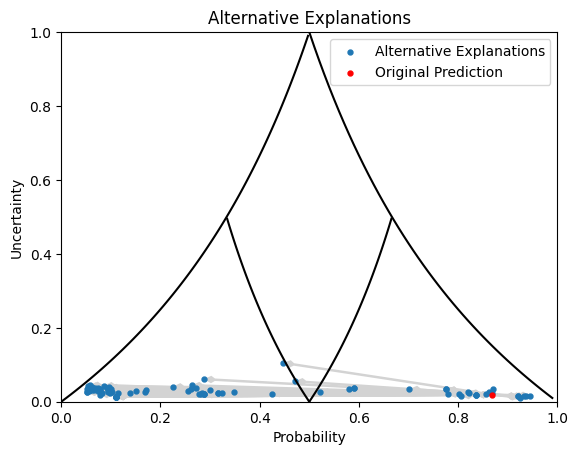

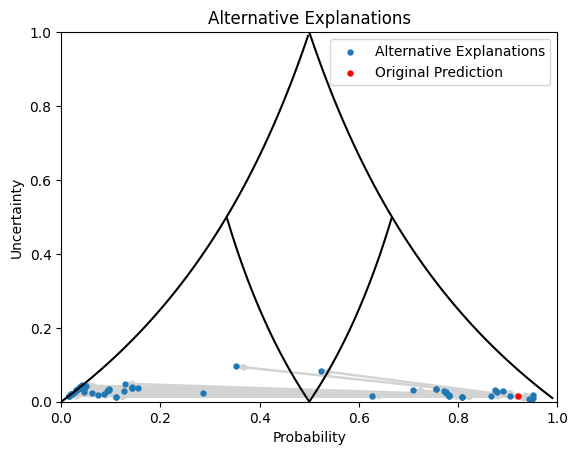

In [20]:
probabilistic_alternatives = regressor.explore_alternatives(
    x_plot, threshold=THRESHOLD_REG
)
probabilistic_alternatives.plot(style="triangular", filter_top=None)
probabilistic_alternatives.add_conjunctions(max_rule_size=MAX_RULE_SIZE)
probabilistic_alternatives.plot(style="triangular", filter_top=None)

Apply all ensured filtering methods to the same probabilistic baseline.

Probabilistic view: super


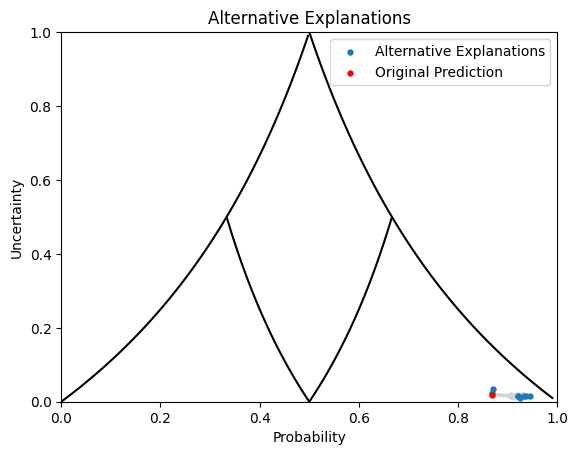

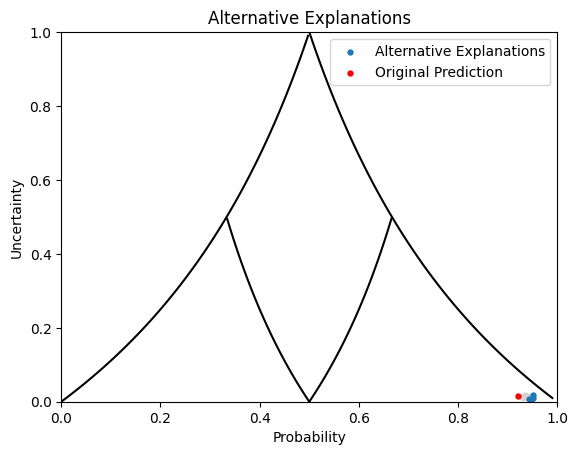

Probabilistic view: semi


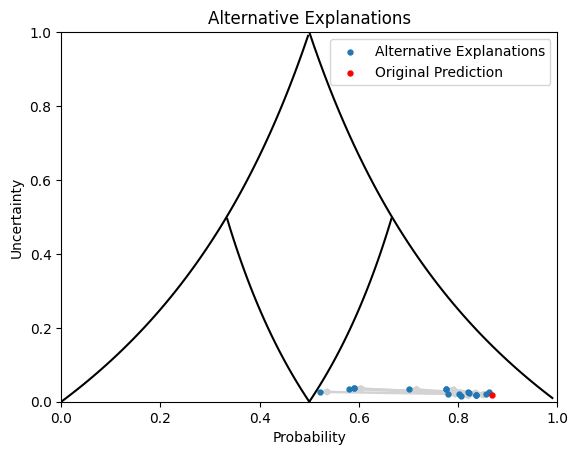

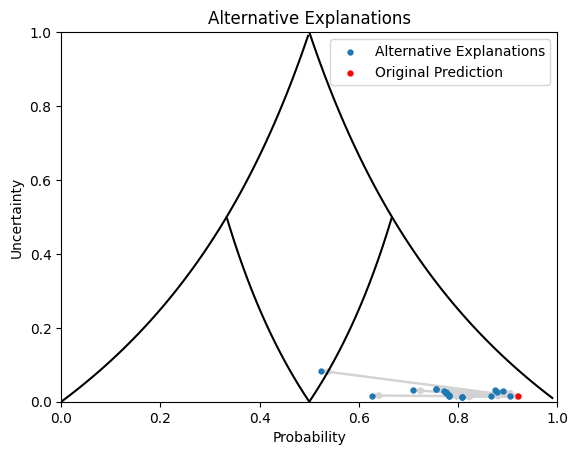

Probabilistic view: counter


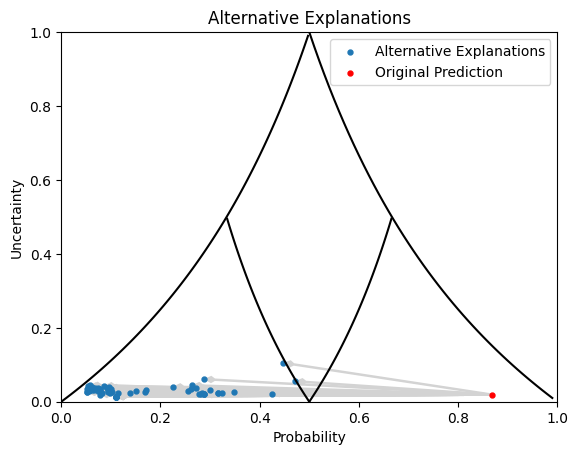

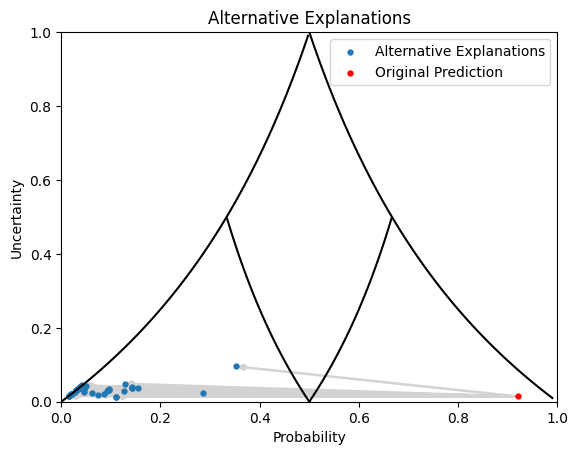

Probabilistic view: ensured


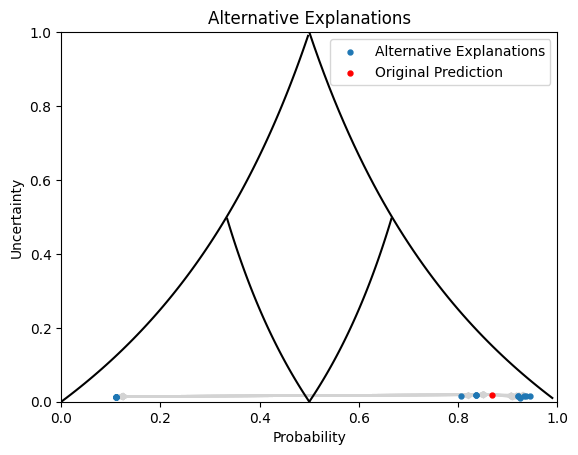

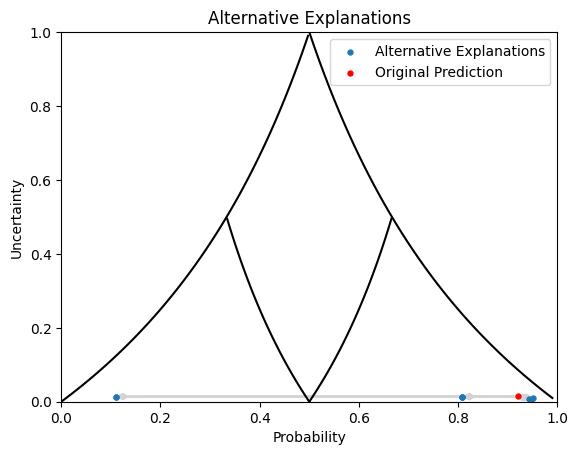

Probabilistic view: pareto


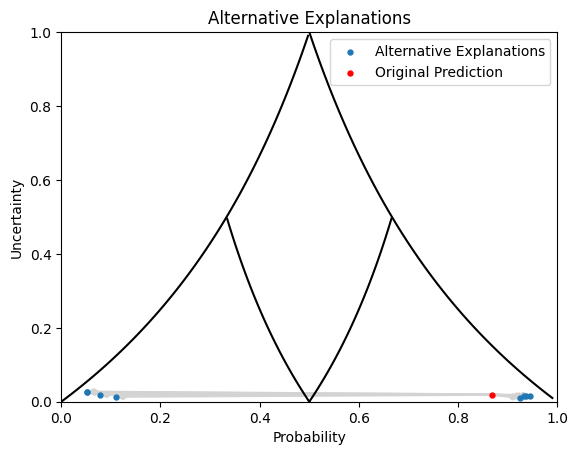

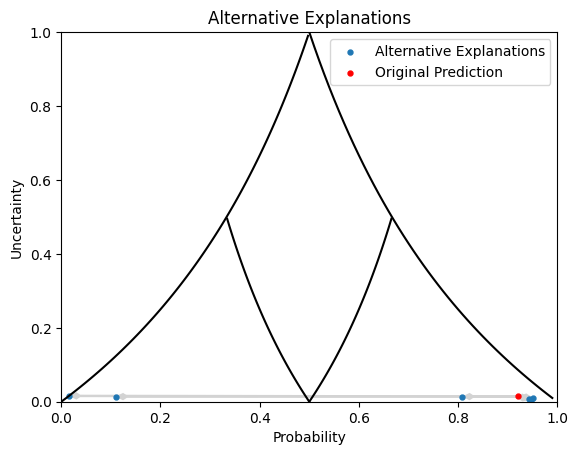

In [21]:
probabilistic_views = {
    "super": probabilistic_alternatives.super_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
    "semi": probabilistic_alternatives.semi_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
    "counter": probabilistic_alternatives.counter_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
    "ensured": probabilistic_alternatives.ensured_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
    "pareto": probabilistic_alternatives.pareto_explanations(
        include_potential=INCLUDE_POTENTIAL
    ),
}

for name, view in probabilistic_views.items():
    print(f"Probabilistic view: {name}")
    view.plot(
        style="triangular",
        rnk_metric="ensured",
        rnk_weight=0.5,
        filter_top=None,
    )

Probabilistic baseline ranking sweep and conjunction example (`max_rule_size=MAX_RULE_SIZE`).

Baseline ranking with rnk_weight=-1.0 and filter_top=3


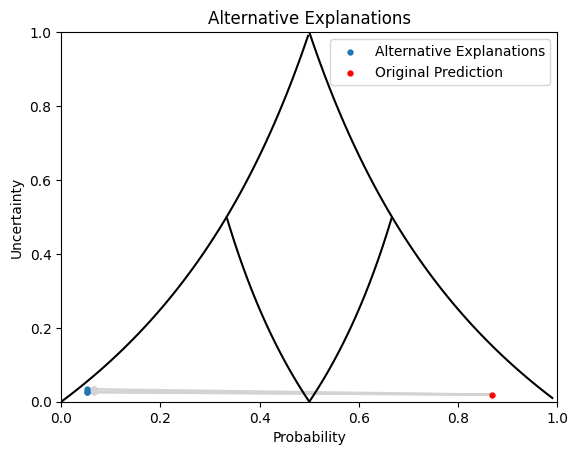

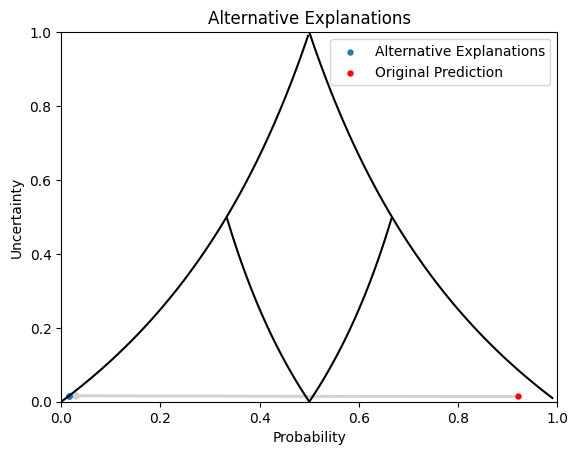

Baseline ranking with rnk_weight=-0.5 and filter_top=3


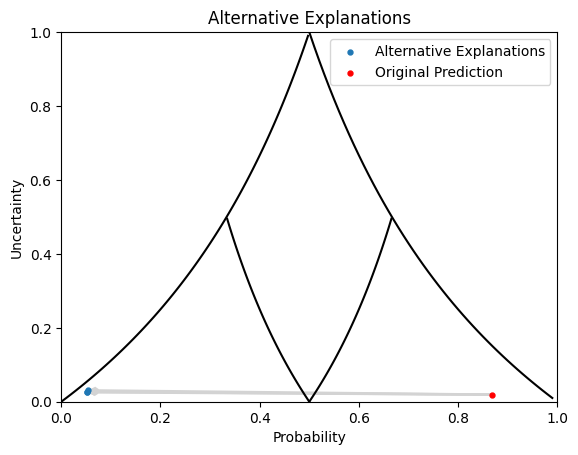

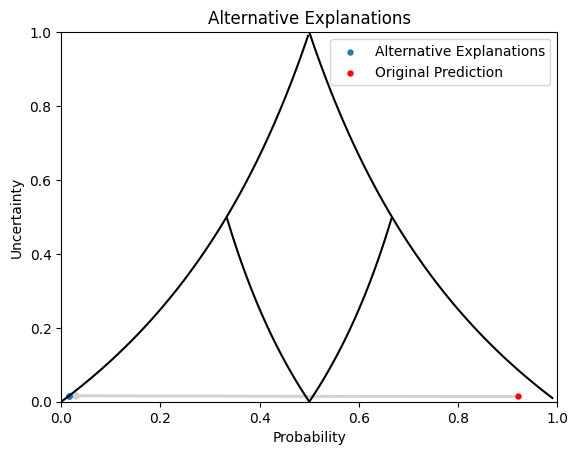

Baseline ranking with rnk_weight=0.0 and filter_top=3


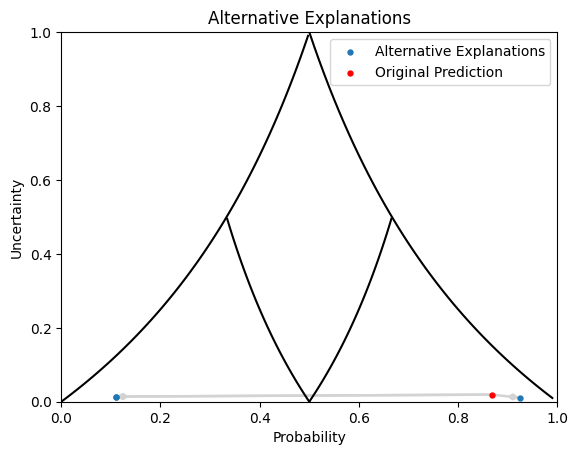

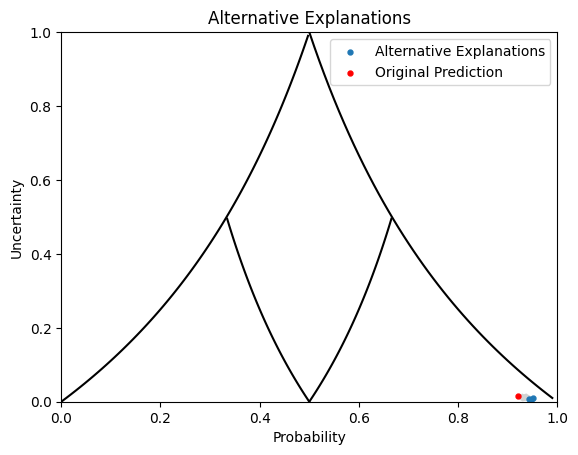

Baseline ranking with rnk_weight=0.5 and filter_top=3


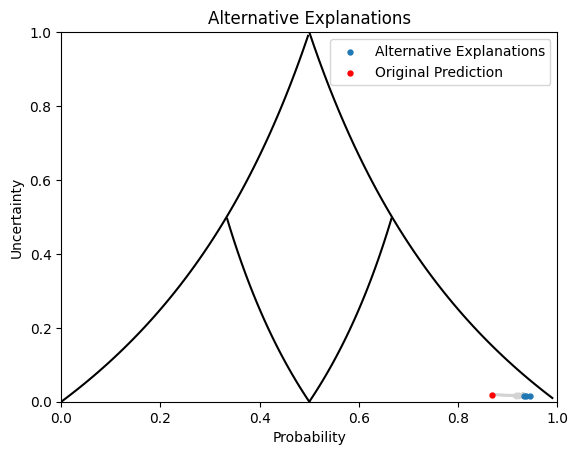

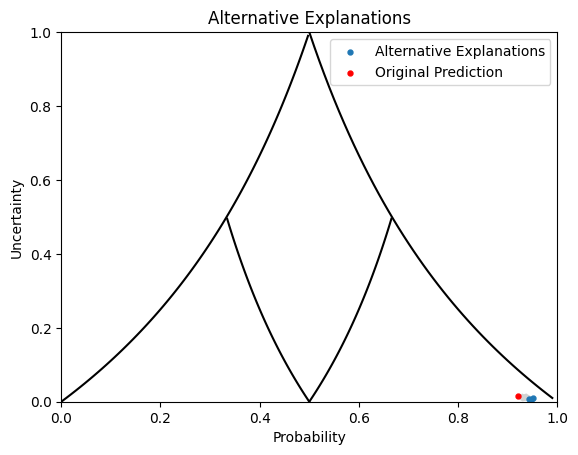

Baseline ranking with rnk_weight=1.0 and filter_top=3


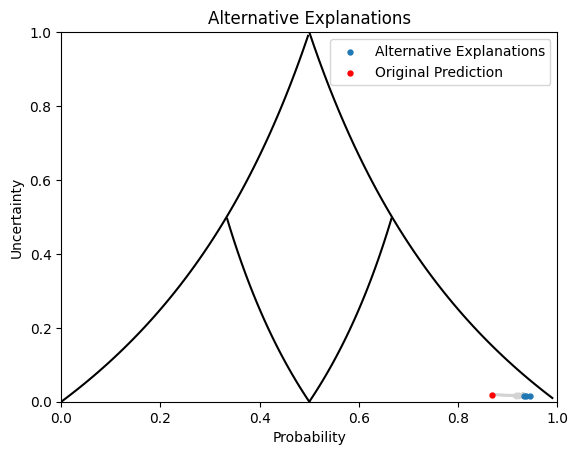

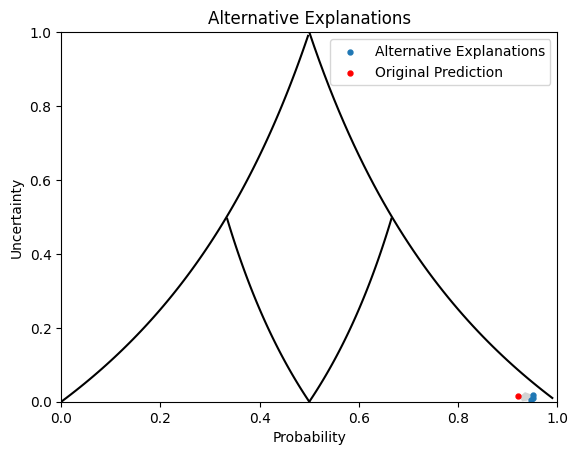

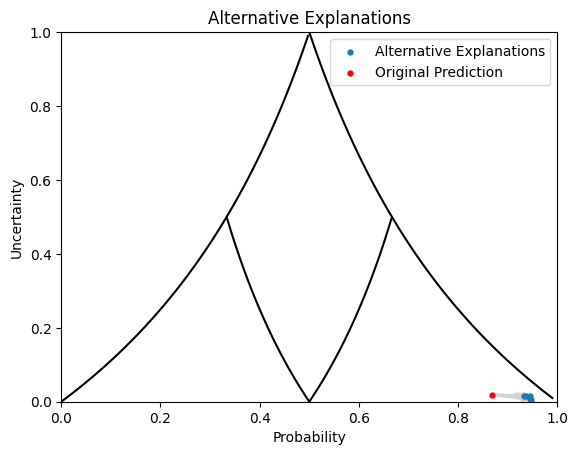

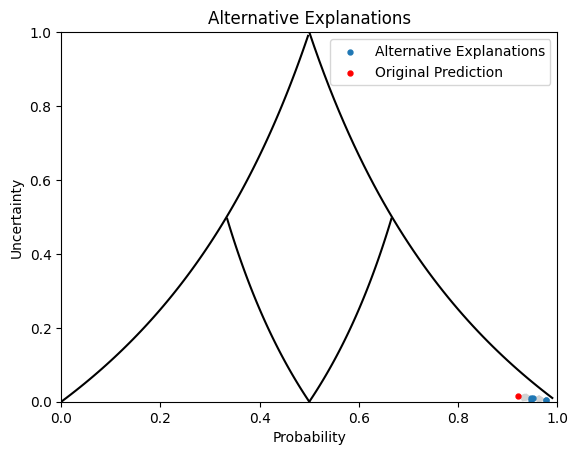

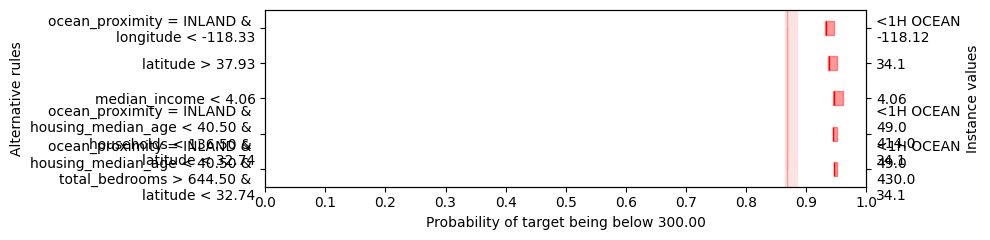

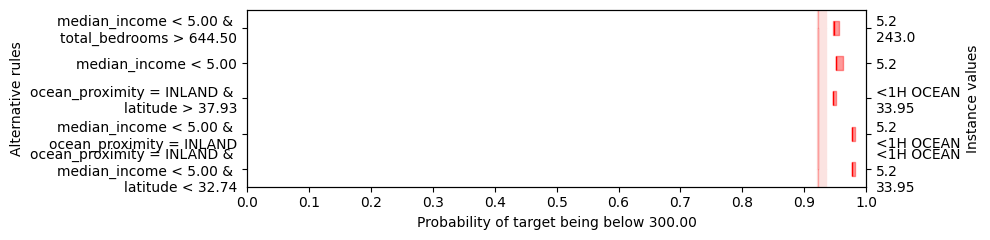

In [22]:
for weight in RNK_WEIGHTS:
    print(f"Baseline ranking with rnk_weight={weight} and filter_top=3")
    probabilistic_alternatives.plot(
        style="triangular",
        rnk_metric="ensured",
        rnk_weight=weight,
        filter_top=3,
    )

prob_ensured_conj = probabilistic_views["ensured"].add_conjunctions(
    max_rule_size=MAX_RULE_SIZE
)
prob_ensured_conj.plot(
    style="triangular",
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=FILTER_TOP_DEFAULT,
    
 )
prob_ensured_conj.plot(
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=FILTER_TOP_DEFAULT,
    
 )

Single probabilistic explanation example (pareto view), triangular and regular styles.

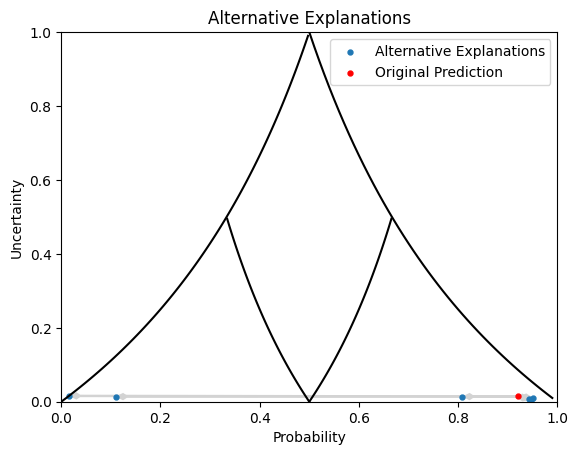

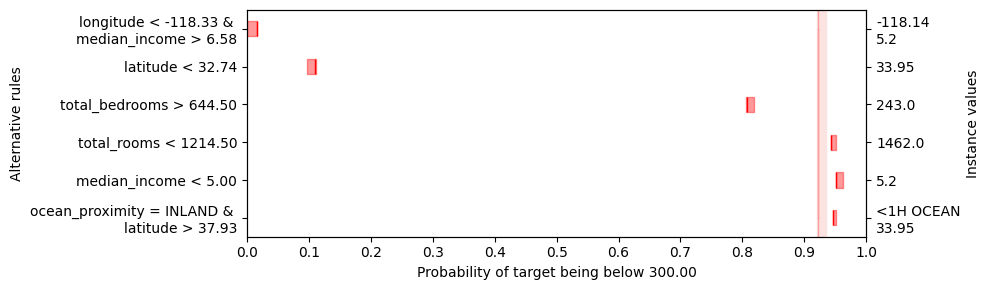

In [23]:
probabilistic_views["pareto"][1].plot(
    style="triangular",
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=None,
 )
probabilistic_views["pareto"][1].plot(
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=None,
 )

## Plain regression alternatives (no threshold)
We start with global plots to show the difference between using a difficulty estimator and not using one. When not using a difficulty estimator, all regression intervals are identical, indicating that the model does not distinguish between different difficulty levels in its predictions.

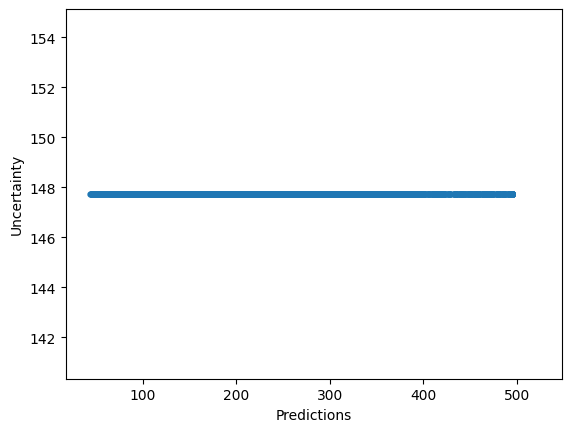

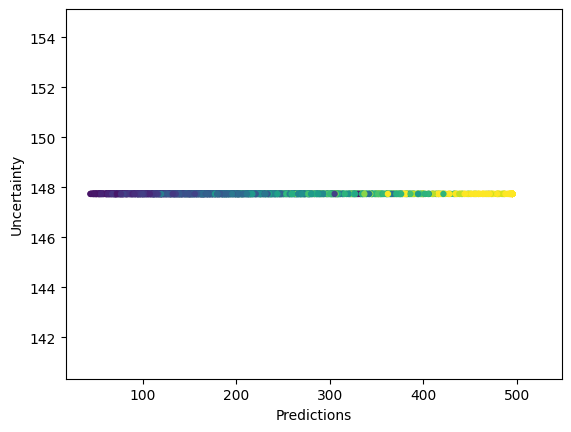

In [24]:
regressor.plot(x_test, show=False)
regressor.plot(x_test, y_test, show=False)

In order to get different intervals, we need to use a difficulty estimator. We can then apply the same ensured filtering methods as before to the plain regression baseline.

In [25]:
from crepes.extras import DifficultyEstimator

regressor.set_difficulty_estimator(DifficultyEstimator().fit(X=X_prop_train, learner=regressor.learner, scaler=True))

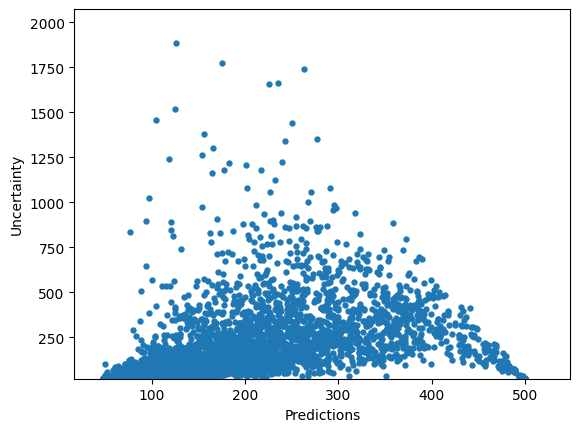

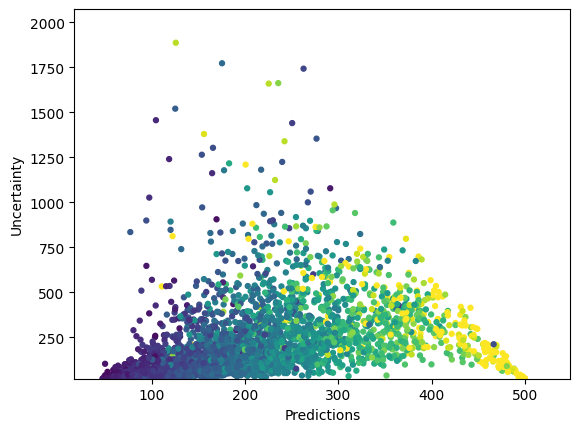

In [26]:
regressor.plot(x_test, show=False)
regressor.plot(x_test, y_test, show=False)

Again, start with all alternatives in a triangular baseline before applying ensured filters.

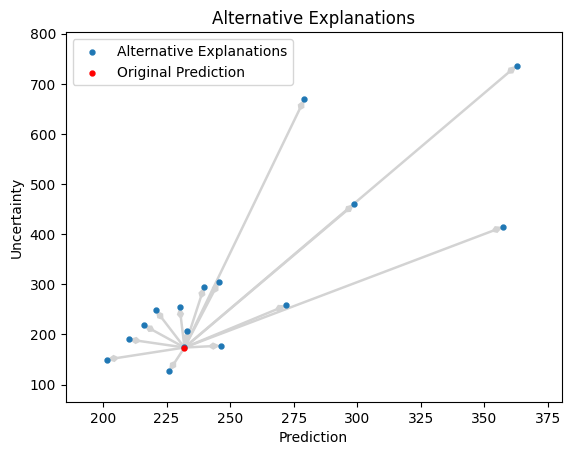

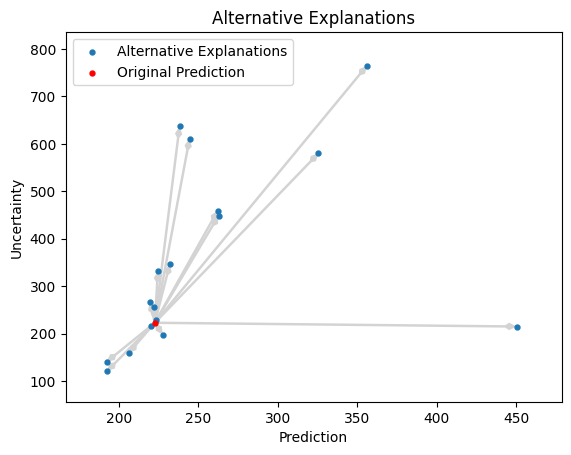

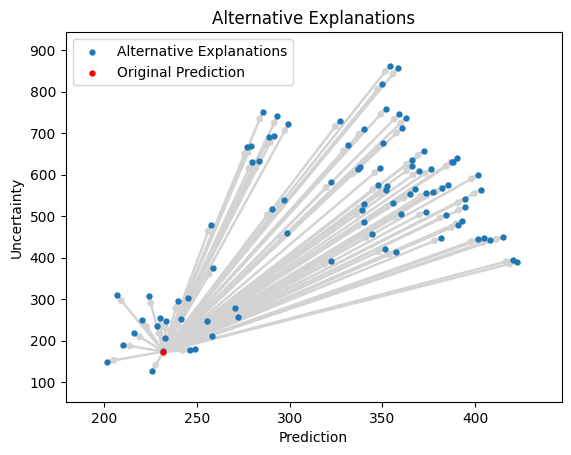

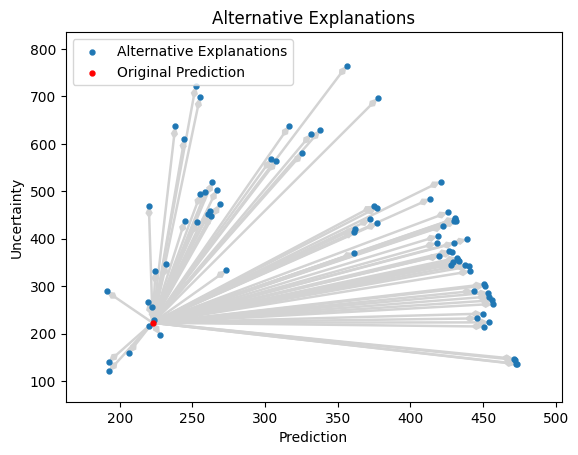

In [27]:
plain_alternatives = regressor.explore_alternatives(x_plot)
plain_alternatives.plot(style="triangular", filter_top=None)
plain_alternatives.add_conjunctions(max_rule_size=MAX_RULE_SIZE)
plain_alternatives.plot(style="triangular", filter_top=None)

Apply the same ensured filters and triangular ensured-ranking plots to plain regression alternatives.

Plain regression view without potentials: super


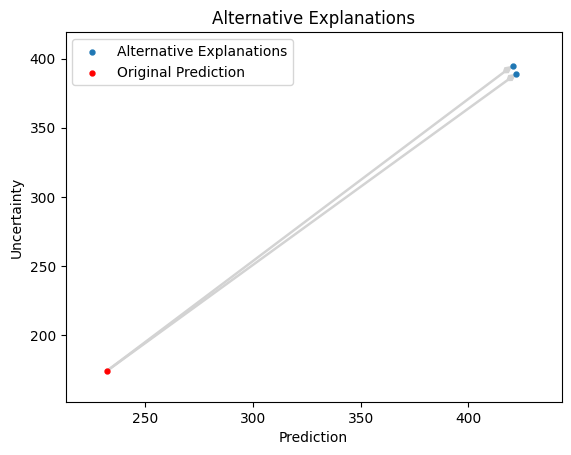

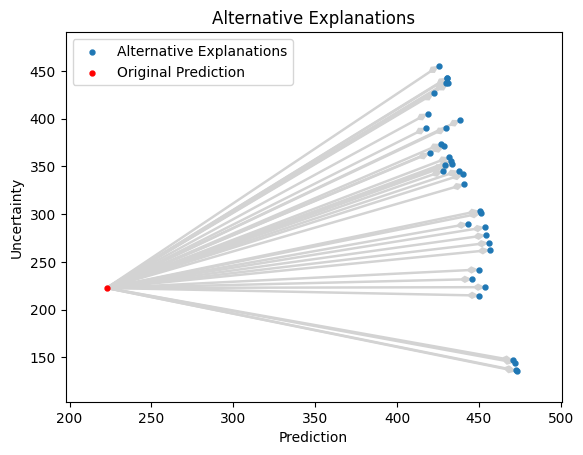

Plain regression view without potentials: semi
Plain regression view without potentials: counter
Plain regression view without potentials: ensured


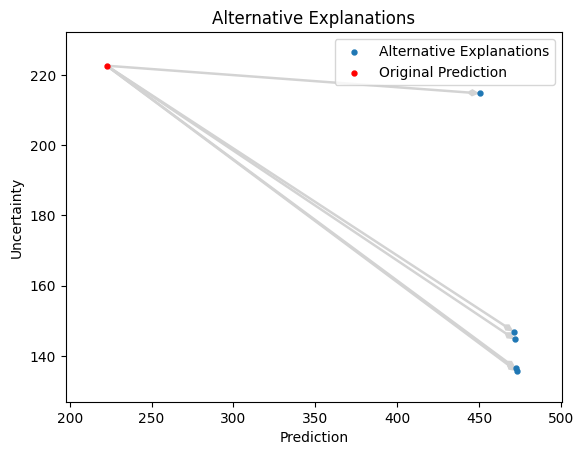

Plain regression view without potentials: pareto


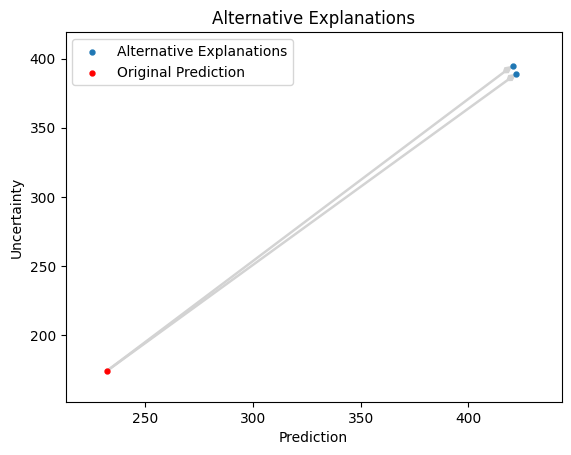

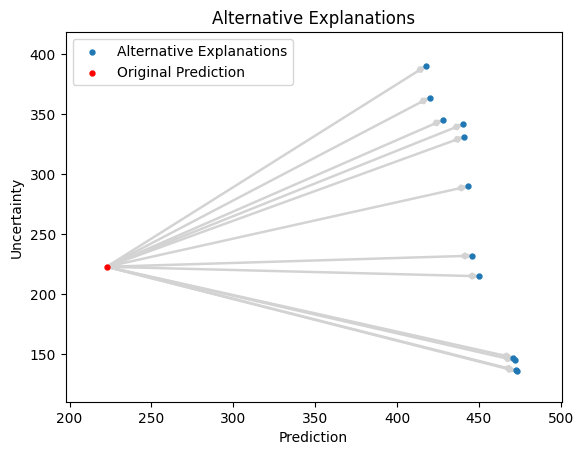

In [28]:
plain_views = {
    "super": plain_alternatives.super_explanations(
        include_potential=False
    ),
    "semi": plain_alternatives.semi_explanations(
        include_potential=False
    ),
    "counter": plain_alternatives.counter_explanations(
        include_potential=False
    ),
    "ensured": plain_alternatives.ensured_explanations(
        include_potential=False
    ),
    "pareto": plain_alternatives.pareto_explanations(
        include_potential=False
    ),
}

for name, view in plain_views.items():
    print(f"Plain regression view without potentials: {name}")
    view.plot(
        style="triangular",
        rnk_metric="ensured",
        rnk_weight=0.5,
        filter_top=None,
    )

Plain regression view with potentials: super


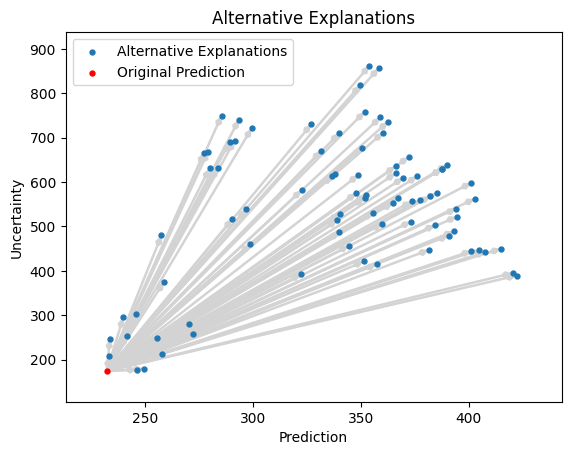

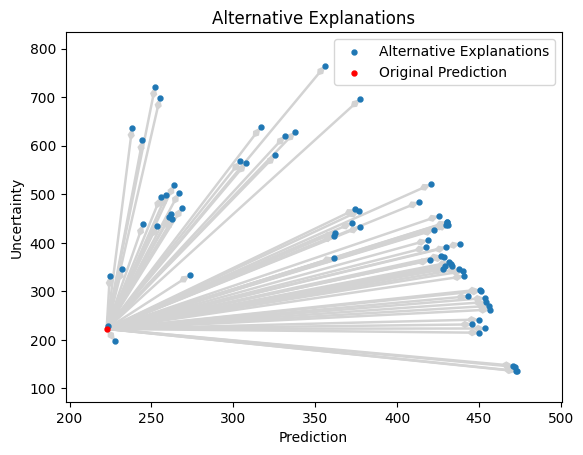

Plain regression view with potentials: semi


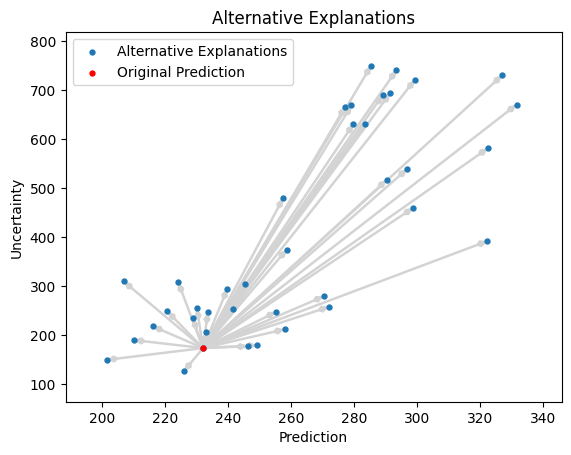

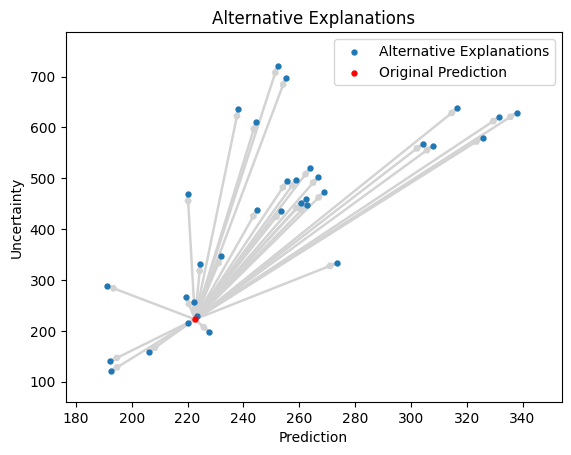

Plain regression view with potentials: counter


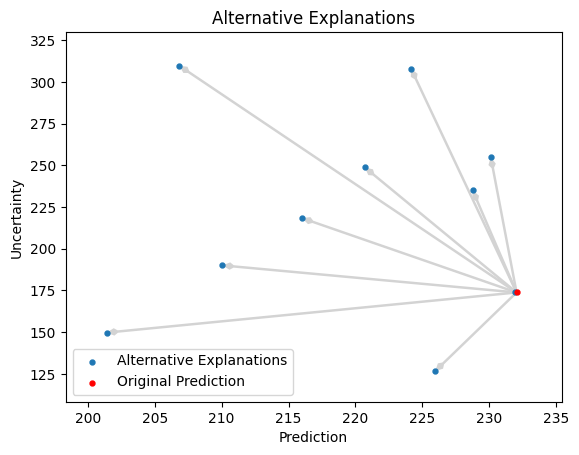

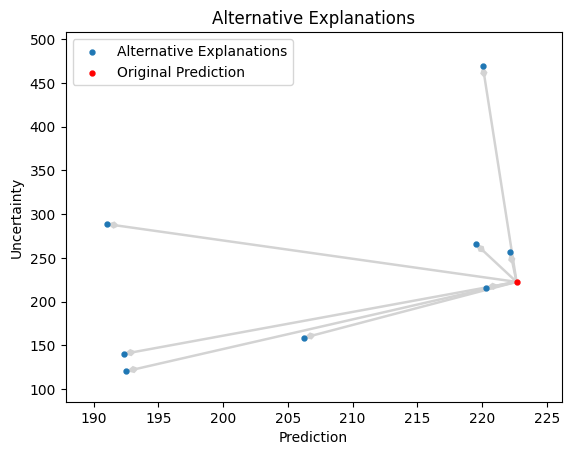

Plain regression view with potentials: ensured


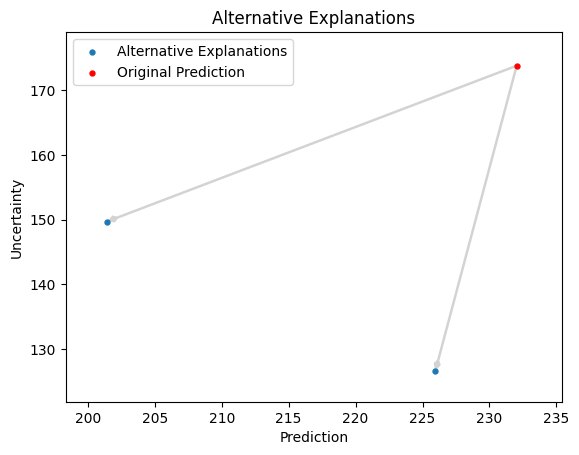

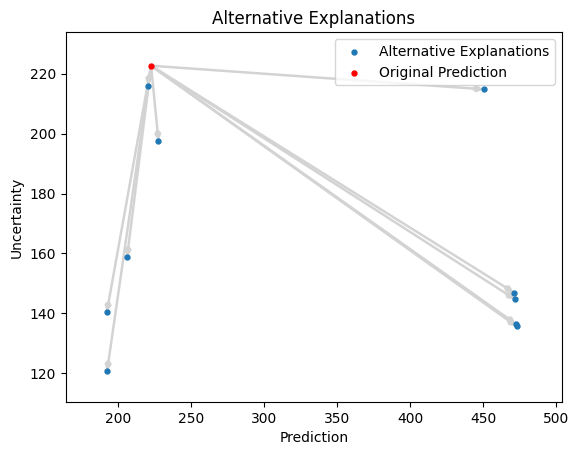

Plain regression view with potentials: pareto


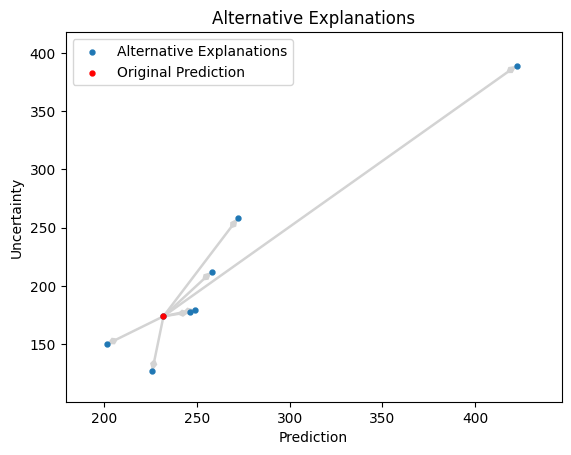

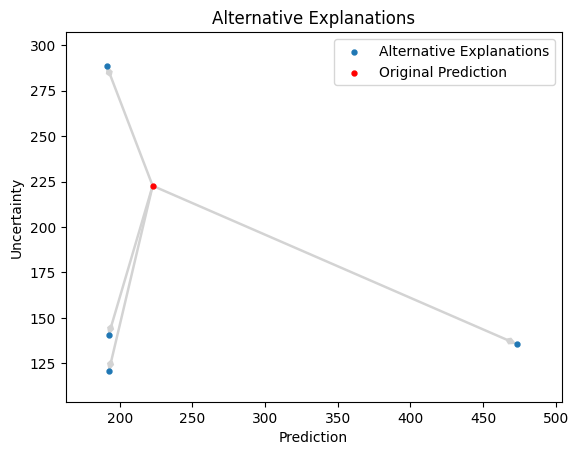

In [29]:
plain_views = {
    "super": plain_alternatives.super_explanations(
        include_potential=True
    ),
    "semi": plain_alternatives.semi_explanations(
        include_potential=True
    ),
    "counter": plain_alternatives.counter_explanations(
        include_potential=True
    ),
    "ensured": plain_alternatives.ensured_explanations(
        include_potential=True
    ),
    "pareto": plain_alternatives.pareto_explanations(
        include_potential=True
    ),
}

for name, view in plain_views.items():
    print(f"Plain regression view with potentials: {name}")
    view.plot(
        style="triangular",
        rnk_metric="ensured",
        rnk_weight=0.5,
        filter_top=None,
    )

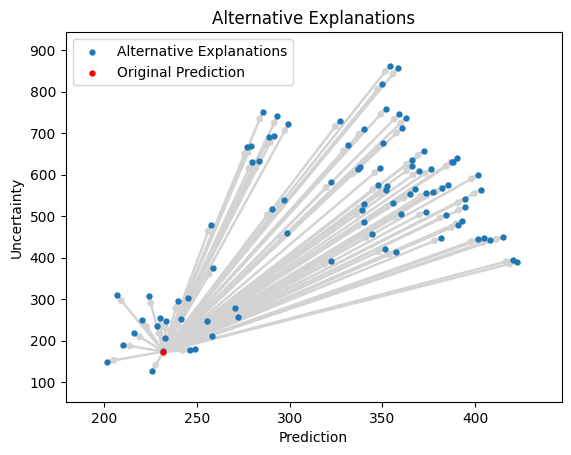

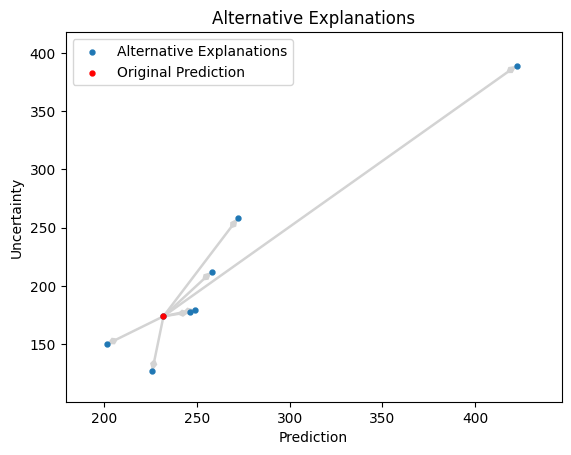

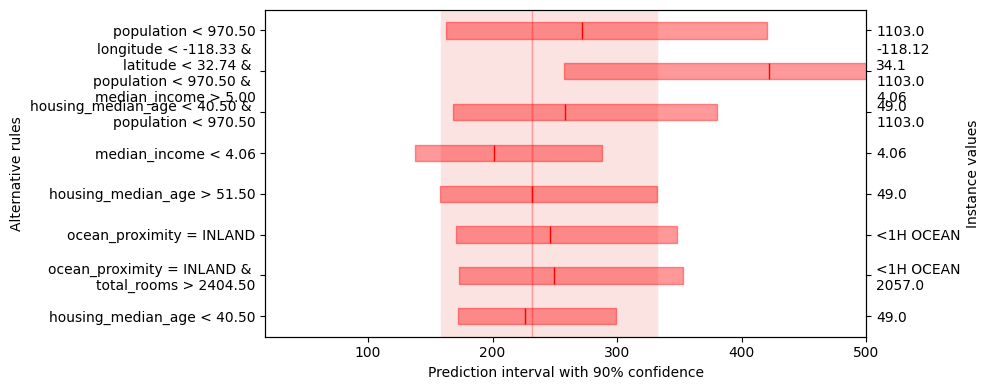

In [30]:
plain_alternatives[0].plot(
    style="triangular",
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=None,
)
plain_views["pareto"][0].plot(
    style="triangular",
    filter_top=None,
)
plain_views["pareto"][0].plot(
    filter_top=None,
)

Single plain-regression explanation from the pareto view, shown with triangular and regular style.

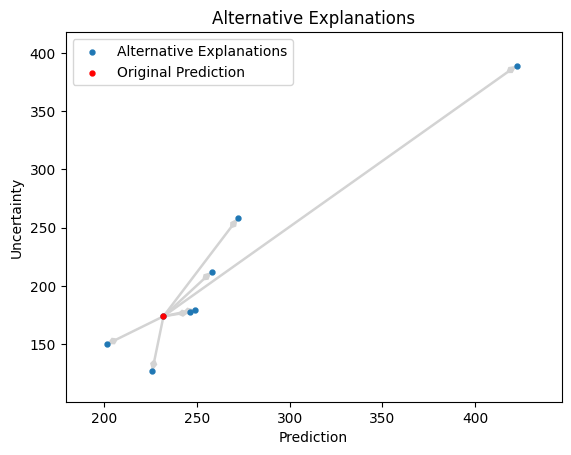

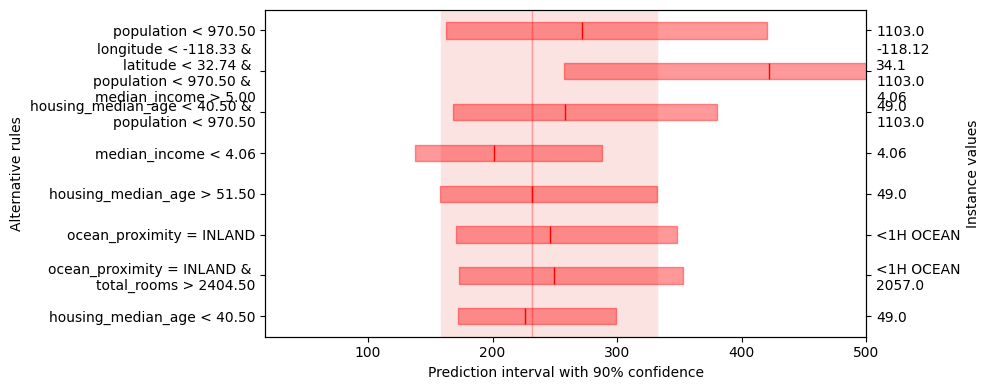

In [31]:
plain_views["pareto"][0].plot(
    style="triangular",
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=10,
    
 )
plain_views["pareto"][0].plot(
    rnk_metric="ensured",
    rnk_weight=0.5,
    filter_top=10,
    
 )

## Notes
- Baseline-first rule used everywhere: triangular plot before any ensured filtering.
- Method names used in this notebook: `super_explanations`, `semi_explanations`, `counter_explanations`, `ensured_explanations`, `pareto_explanations`.
- Conjunction control uses `max_rule_size` (here globally set to 10).

In [32]:
print("Configured ensured methods and ranking settings:")
print("methods = ['super', 'semi', 'counter', 'ensured', 'pareto']")
print(f"MAX_RULE_SIZE={MAX_RULE_SIZE}")
print(f"FILTER_TOP_DEFAULT={FILTER_TOP_DEFAULT}")
print(f"RNK_WEIGHTS={RNK_WEIGHTS}")

Configured ensured methods and ranking settings:
methods = ['super', 'semi', 'counter', 'ensured', 'pareto']
MAX_RULE_SIZE=4
FILTER_TOP_DEFAULT=5
RNK_WEIGHTS=[-1.0, -0.5, 0.0, 0.5, 1.0]


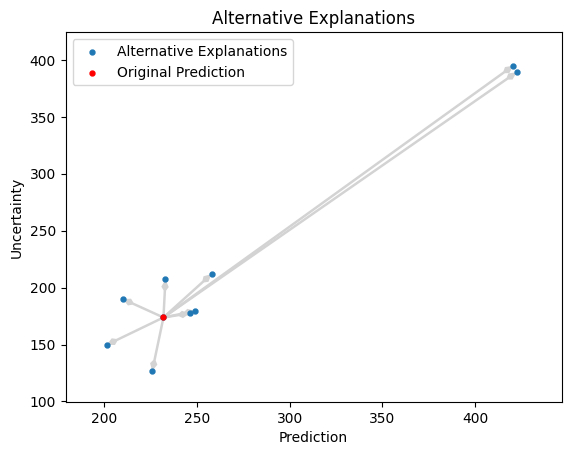

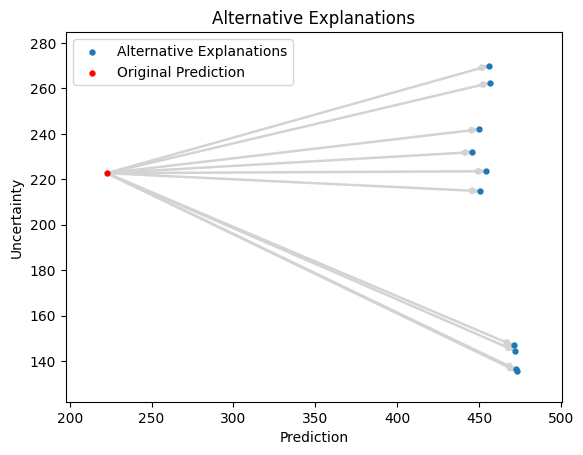

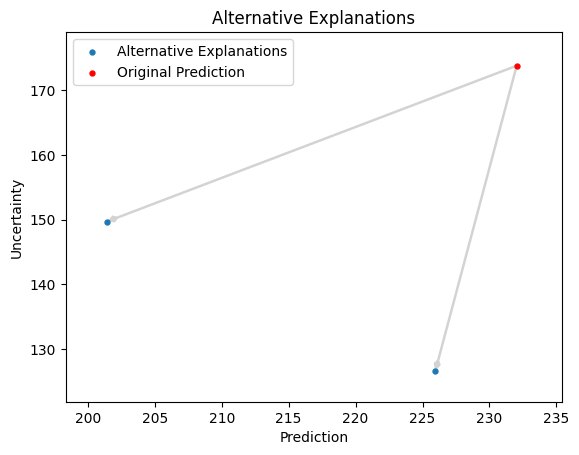

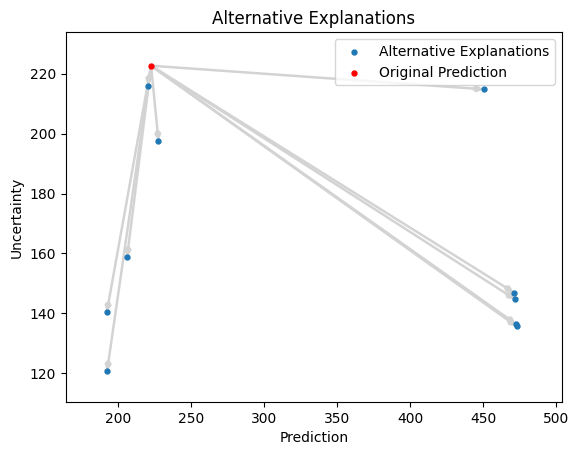

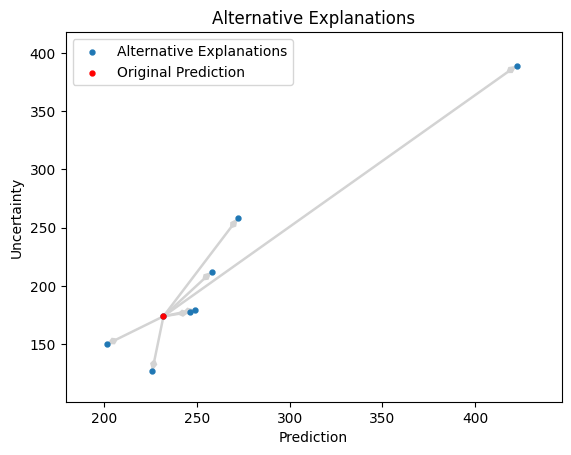

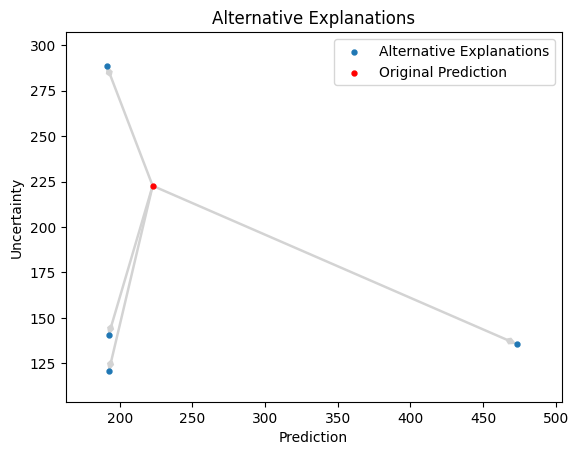

In [33]:
# Optional: compact side-by-side baseline vs ensured-vs-pareto for plain regression
plain_alternatives.plot(style="triangular", filter_top=10, )
plain_views["ensured"].plot(
    style="triangular", rnk_metric="ensured", rnk_weight=0.5, filter_top=10, 
)
plain_views["pareto"].plot(
    style="triangular", rnk_metric="ensured", rnk_weight=0.5, filter_top=10, 
)

This notebook intentionally stays alternatives-only and ensured-focused.
You can now reuse the same pattern on your own data:
1. `explore_alternatives(...)`
2. **baseline triangular plot**
3. ensured filtering (`super`/`semi`/`counter`/`ensured`/`pareto`)
4. ranking + conjunction analysis

In [34]:
# Quick smoke list of supported ensured filter calls on collections
supported_filters = [
    "super_explanations",
    "semi_explanations",
    "counter_explanations",
    "ensured_explanations",
    "pareto_explanations",
]
print(supported_filters)

['super_explanations', 'semi_explanations', 'counter_explanations', 'ensured_explanations', 'pareto_explanations']


End of ensured alternatives notebook.